In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

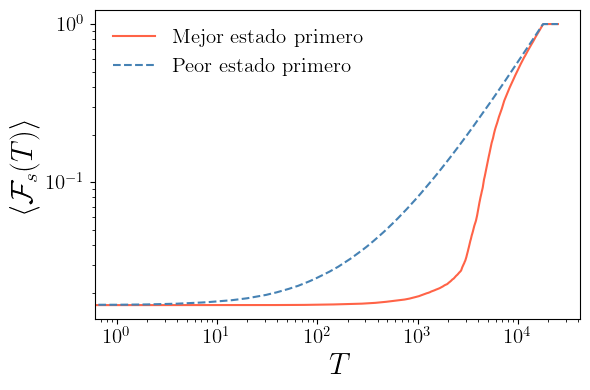

In [2]:
avg_repair = np.load('F_Deterministic_Strategy.npy', allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
t_repair = np.arange(T_repair + 1)

strategies = ['best', 'worst']

strategy_config = {
    'best':  ('Mejor estado primero', 'tomato', '-', 1.5),
    'worst': ('Peor estado primero',  'steelblue', '--', 1.5),
}

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

for s in strategies:
    label, color, style, lw = strategy_config[s]

    plt.loglog(
        t_repair,
        avg_repair[s],
        linestyle=style,
        color=color,
        linewidth=lw,
        label=label
    )


plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(
    loc='upper left',
    frameon=False,
    fontsize=15
)
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Deterministica.pdf', bbox_inches="tight")

plt.show()

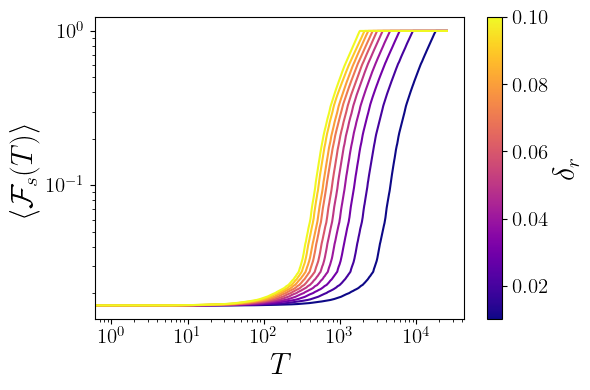

In [3]:
avg_repair = np.load('F_Deterministic_deltar_Best.npy', allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5,
        label=rf"$\delta_r = {d:.2f}$"
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Deterministica_delta_r_best.pdf',
            bbox_inches="tight")

plt.show()

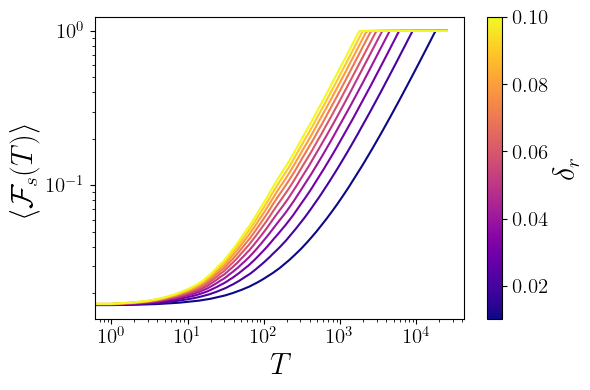

In [4]:
avg_repair = np.load('F_Deterministic_deltar_Worst.npy', allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5,
        label=rf"$\delta_r = {d:.2f}$"
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Deterministica_delta_r_worst.pdf',
            bbox_inches="tight")

plt.show()